In [13]:
!git clone https://github.com/aishindi/ai-saas-ad-strategy-copilot.git
%cd ai-saas-ad-strategy-copilot
!pip install -q -r requirements.txt

Cloning into 'ai-saas-ad-strategy-copilot'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 141 (delta 41), reused 121 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 147.30 KiB | 16.37 MiB/s, done.
Resolving deltas: 100% (41/41), done.
/content/project_repo/ai-saas-ad-strategy-copilot-main/ai-saas-ad-strategy-copilot


In [2]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 125.3 MB/s eta 0:00:00


In [4]:
# Install required system package first
!apt-get update -qq
!apt-get install -y zstd

# Install Ollama
!curl -fsSL https://ollama.com/install.sh | sh

# Start Ollama server
import subprocess
import time

ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

# Wait for server startup
time.sleep(10)

print("Ollama server started")

# Pull models
!ollama pull mistral
!ollama pull llama3

# Verify models
!ollama list

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 59 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (18.5 MB/s)
Selecting previously unselected package zstd.
(Reading database ... 122363 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Cleaning up old version at /usr/local/lib/ollama
>>> In

In [5]:
import os
os.environ["MODEL_MODE"] = "ollama"
os.environ["MODEL_SMALL"] = "mistral"
os.environ["MODEL_LARGE"] = "llama3"
os.environ["WEB_SEARCH_MODE"] = "mock"

In [6]:
!python database/seed_data.py

Database seeded successfully.


In [7]:
!python -m evaluation.run_evaluation


RUNNING STANDARD EVALUATION
Queries: 20 | Models: ['mistral', 'llama3'] | Strategies: ['baseline', 'meta', 'meta_reflect']
Total runs: 120

[1/120] Query 1/20 | model=mistral | strategy=baseline
Query: We have a $50,000 Q3 budget for a B2B SaaS launch. How should we allocate it across platforms?
Result: FAIL | score=1/6 | accuracy=16.67% | time=120.099s | tool=hybrid

[2/120] Query 2/20 | model=mistral | strategy=baseline
Query: Which audience segment historically produced the highest ROI?
Result: FAIL | score=2/6 | accuracy=33.33% | time=34.633s | tool=database

[3/120] Query 3/20 | model=mistral | strategy=baseline
Query: Compare LinkedIn Ads and Google Ads performance for enterprise SaaS campaigns.
Result: PASS | score=4/6 | accuracy=66.67% | time=11.487s | tool=database

[4/120] Query 4/20 | model=mistral | strategy=baseline
Query: Based on past campaigns, what messaging themes worked best?
Result: FAIL | score=2/6 | accuracy=33.33% | time=9.946s | tool=hybrid

[5/120] Query 5/20 

In [8]:
!python evaluation/summarize_results.py

Loaded: evaluation_results/standard_results_20260521_025601.json

Model Summary
model | avg_score | accuracy_percent | pass_rate_percent | avg_latency_sec | runs
llama3 | 5.43 | 90.56% | 93.33% | 17.36 | 60
mistral | 5.25 | 87.50% | 88.33% | 25.70 | 60

Prompt Strategy Summary
strategy | avg_score | accuracy_percent | pass_rate_percent | runs
baseline | 4.03 | 67.08% | 72.50% | 40
meta | 6.00 | 100.00% | 100.00% | 40
meta_reflect | 6.00 | 100.00% | 100.00% | 40

Model + Strategy Summary
model | strategy | avg_score | accuracy_percent | pass_rate_percent | runs
llama3 | baseline | 4.30 | 71.66% | 80.00% | 20
llama3 | meta | 6.00 | 100.00% | 100.00% | 20
llama3 | meta_reflect | 6.00 | 100.00% | 100.00% | 20
mistral | baseline | 3.75 | 62.50% | 65.00% | 20
mistral | meta | 6.00 | 100.00% | 100.00% | 20
mistral | meta_reflect | 6.00 | 100.00% | 100.00% | 20


In [9]:
!python evaluation/plot_results.py

Loaded: evaluation_results/standard_results_20260521_025601.json
Loaded: evaluation_results/cache_results_20260521_025601.json
Saved model_latency.png
Saved prompt_strategy_scores.png
Saved cache_comparison.png
Done. Plots saved in evaluation_results/plots


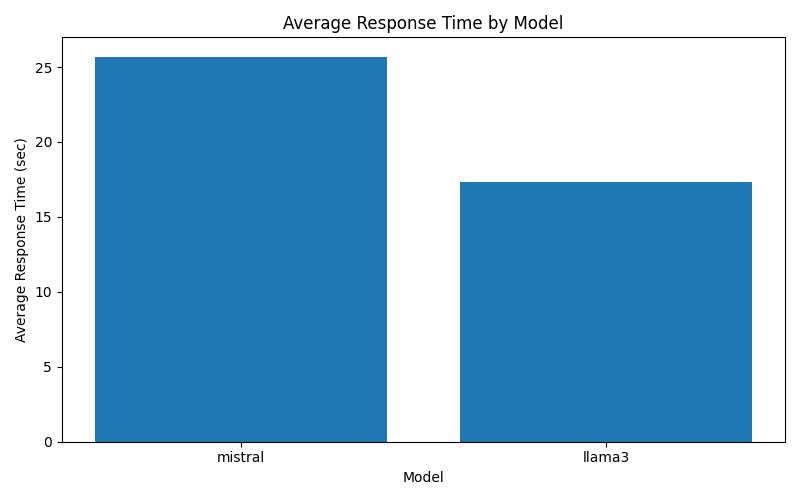

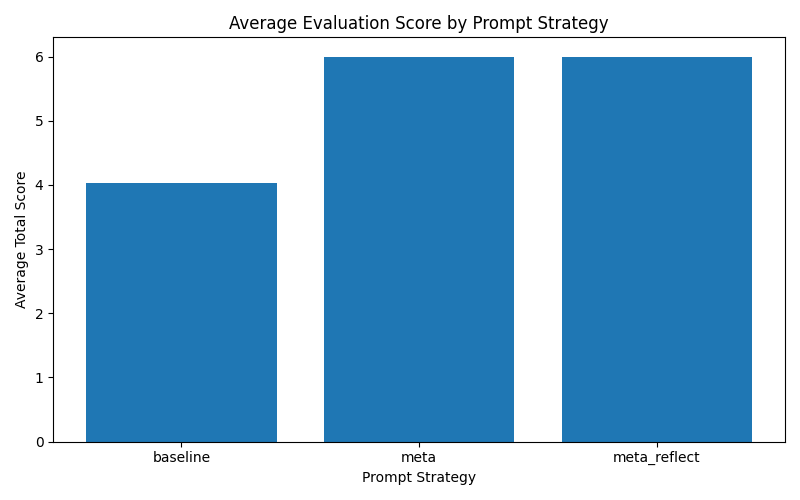

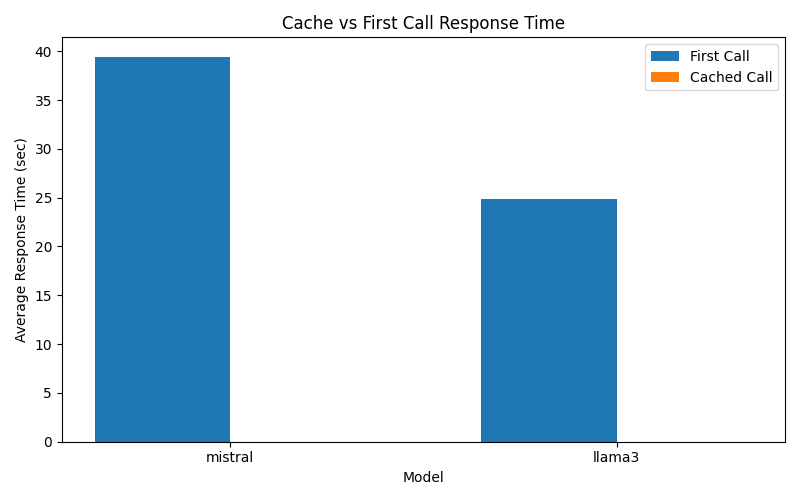

In [10]:
from IPython.display import Image, display
import os

for path in [
    "evaluation_results/plots/model_latency.png",
    "evaluation_results/plots/prompt_strategy_scores.png",
    "evaluation_results/plots/cache_comparison.png",
]:
    if os.path.exists(path):
        display(Image(path))
    else:
        print("Missing:", path)

In [11]:
!zip -r evaluation_results.zip evaluation_results

  adding: evaluation_results/ (stored 0%)
  adding: evaluation_results/model_strategy_summary_20260521_025601.csv (deflated 50%)
  adding: evaluation_results/query_run_log_20260521_025601.csv (deflated 85%)
  adding: evaluation_results/cache_results_20260521_025601.json (deflated 83%)
  adding: evaluation_results/security_results_20260521_025601.json (deflated 74%)
  adding: evaluation_results/model_summary_20260521_025601.csv (deflated 20%)
  adding: evaluation_results/.DS_Store (deflated 85%)
  adding: evaluation_results/query_summary_20260521_025601.csv (deflated 50%)
  adding: evaluation_results/strategy_summary_20260521_025601.csv (deflated 30%)
  adding: evaluation_results/evaluation_summary_20260521_025601.json (deflated 81%)
  adding: evaluation_results/plots/ (stored 0%)
  adding: evaluation_results/plots/cache_comparison.png (deflated 19%)
  adding: evaluation_results/plots/model_latency.png (deflated 20%)
  adding: evaluation_results/plots/prompt_strategy_scores.png (deflate

In [12]:
from google.colab import files
files.download("evaluation_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>